In [102]:
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import FancyArrowPatch

### Rotation

In [ ]:
# 1. Generate N=100 points
np.random.seed(42)
N = 100
mean = [0, 0]
cov_matrix = [[8, 4], [4, 4]]
points = np.random.multivariate_normal(mean, cov_matrix, N)

# 2. Get Eigenvectors and Eigenvalues
sample_cov = np.cov(points.T)
eigenvalues, eigenvectors = np.linalg.eig(sample_cov)

# --- NEW STEP: Sort to find the Principal Eigenvector ---
# np.linalg.eig doesn't guarantee order. We want the one with the largest eigenvalue.
max_idx = np.argmax(eigenvalues)
principal_val = eigenvalues[max_idx]
principal_vec = eigenvectors[:, max_idx]

# Scale it: eigenvector * sqrt(eigenvalue) * factor
# We shape it as (2, 1) so matrix multiplication works easily later
scaled_principal_vec = (principal_vec * np.sqrt(principal_val) * 2).reshape(2, 1)

# 3. Setup the Rotation Logic
def get_rotation_matrix(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], 
                     [s,  c]])

# 4. Visualization Setup
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-7.5, 7.5)
ax.set_ylim(-7.5, 7.5)
ax.set_aspect('equal')

# # Style updates as requested
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
# ax.set_xlabel('Neuron 1')
# ax.set_ylabel('Neuron 2')
# ax.set_title(f"Neuron activity in drift")

ax.axis('off')

# Plot elements
scatter_plot = ax.scatter([], [], c='black', alpha=1.0, label='Data Points')

# Quiver for ONLY ONE arrow
# We initialize it with one arrow at (0,0)
# arrows = ax.quiver([0], [0], [0], [0], 
#                    color='red', scale=1, scale_units='xy', angles='xy',
#                    label='Principal Component')

def update(frame):
    theta = np.radians(frame)
    R = get_rotation_matrix(theta)
    
    # Rotate Points
    # (2x2) @ (2xN) -> Transpose back to (Nx2)
    rotated_points = (R @ points.T).T
    
    # Rotate ONLY the Principal Eigenvector
    # (2x2) @ (2x1) -> Result is (2,1)
    rotated_vec = R @ scaled_principal_vec
    
    # Update Scatter
    scatter_plot.set_offsets(rotated_points)
    
    return scatter_plot


# Create Animation
anim = FuncAnimation(fig, update, frames=np.arange(0, 360, 10), interval=180, blit=False)
plt.close()  # Prevents static image display in some environments

In [107]:
HTML(anim.to_jshtml())

In [93]:
# save the animation as a GIF (optional)
anim.save('rotating_points_eigenvectors.gif', writer='pillow', fps=30)

### equal variance along both axes

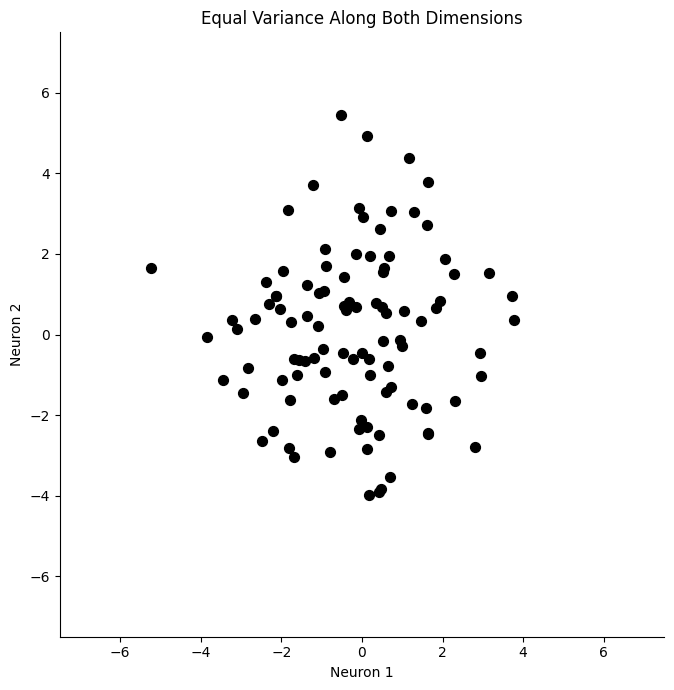

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate points with EQUAL variance along both axes
np.random.seed(42)
N = 100
mean = [0, 0]
# Identity covariance matrix = equal variance, no correlation
cov_matrix = [[4, 0], [0, 4]]
points = np.random.multivariate_normal(mean, cov_matrix, N)

# Get Eigenvectors and Eigenvalues
sample_cov = np.cov(points.T)
eigenvalues, eigenvectors = np.linalg.eig(sample_cov)

# Sort by eigenvalue (largest first)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Scale eigenvectors by sqrt(eigenvalue)
scale_factor = 2.5
# vec1 = eigenvectors[:, 0] * np.sqrt(eigenvalues[0]) * scale_factor
# vec2 = eigenvectors[:, 1] * np.sqrt(eigenvalues[1]) * scale_factor

# Create visualization
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-7.5, 7.5)
ax.set_ylim(-7.5, 7.5)
ax.set_aspect('equal')

# Style
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
# ax.set_xlabel('Neuron 1')
# ax.set_ylabel('Neuron 2')
# ax.set_title("Equal Variance Along Both Dimensions")
ax.axis('off')

# Plot data points
ax.scatter(points[:, 0], points[:, 1], c='black', alpha=1, s=50, label='Data Points')

# Plot eigenvectors as arrows
# ax.quiver([0], [0], [vec1[0]], [vec1[1]], 
#          color='red', scale=1, scale_units='xy', angles='xy', 
#          label='Eigenvector 1', width=0.015)
# ax.quiver([0], [0], [vec2[0]], [vec2[1]], 
#          color='green', scale=1, scale_units='xy', angles='xy', 
#          label='Eigenvector 2', width=0.015)

# ax.legend(loc='upper left')
# ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Null space

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# 1. Generate 100 correlated points
np.random.seed(42)
N = 100
mean = [0, 0]
# Defined covariance to create a distinct oval shape
cov_matrix = [[8, 4], [4, 4]]
points_initial = np.random.multivariate_normal(mean, cov_matrix, N)

# 2. Calculate Initial PCA to determine the "Collapse Axis"
# We need to lock in the direction we are collapsing along (the initial minor axis)
cov_init = np.cov(points_initial.T)
vals_init, vecs_init = np.linalg.eig(cov_init)

# Sort them so we know which is Principal (0) and which is Minor (1)
idx = vals_init.argsort()[::-1]
vals_init = vals_init[idx]
vecs_init = vecs_init[:, idx]

# The Minor Eigenvector (Direction of movement)
minor_vec = vecs_init[:, 1]

# Pre-calculate the projection of every point onto the Minor Vector.
# We will subtract this component gradually.
# Formula: projection = (point . minor_vec) * minor_vec
projections = np.outer(points_initial @ minor_vec, minor_vec)

# 3. Visualization Setup
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-7.5, 7.5)
ax.set_ylim(-7.5, 7.5)
# hide the right and top spines
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
# # ylabel and xlabel
# ax.set_xlabel('Neuron 1')
# ax.set_ylabel('Neuron 2')
# ax.set_aspect('equal')
# # ax.grid(True, linestyle='--', alpha=0.6)
# ax.set_title("Drift in the null space")
ax.axis('off')

# Scatter plot
scatter = ax.scatter([], [], c='black', alpha=1.0, label='Data Points')

# Quiver (Arrows): We create two separate quivers to color them differently
# Red = Principal (Should stay strong), Green = Minor (Should shrink)
arrow_principal = ax.quiver([0], [0], [0], [0], color='red', 
                           scale=1, scale_units='xy', angles='xy', label='Principal Eigenvector', width=0.015)
arrow_minor = ax.quiver([0], [0], [0], [0], color='green', 
                       scale=1, scale_units='xy', angles='xy', label='Minor Eigenvector (Collapsing)', width=0.015)

def update(frame):
    # 'factor' goes from 1.0 down to 0.0, then back to 1.0 (looping effect)
    # We use a sin wave for smooth back-and-forth
    factor = (np.sin(np.radians(frame)) + 1) / 2 
    
    # CALCULATE CURRENT POINTS
    # New Point = Original Point - (Proportion of Minor Component)
    # When factor is 1: Points are original.
    # When factor is 0: Points are fully flattened onto the main axis.
    current_points = points_initial - (projections * (1 - factor))
    
    # REAL-TIME EIGEN CALCULATION
    # Recalculate covariance of the current squashed cloud
    current_cov = np.cov(current_points.T)
    vals, vecs = np.linalg.eig(current_cov)
    
    # Sort again to ensure Red is always Principal
    idx = vals.argsort()[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]
    
    # Scale arrows by sqrt(eigenvalues) * constant
    # Note: When factor -> 0, the minor eigenvalue -> 0, so the green arrow will vanish.
    scale_factor = 2.5
    vec_p = vecs[:, 0] * np.sqrt(vals[0]) * scale_factor
    vec_m = vecs[:, 1] * np.sqrt(vals[1]) * scale_factor
    
    # FLIP CHECK: 
    # Eigenvectors can flip 180 degrees arbitrarily between frames due to math solvers.
    # We check dot product with initial vectors to keep them pointing roughly same way for smoothness.
    if np.dot(vec_p, vecs_init[:, 0]) < 0: vec_p = -vec_p
    if np.dot(vec_m, vecs_init[:, 1]) < 0: vec_m = -vec_m

    # Update Scatter
    scatter.set_offsets(current_points)
    
    # Update Arrows
    arrow_principal.set_UVC(vec_p[0], vec_p[1])
    arrow_minor.set_UVC(vec_m[0], vec_m[1])
    
    return scatter, arrow_principal, arrow_minor

# Frames go 0->360 for a full loop of squashing and expanding
anim = FuncAnimation(fig, update, frames=np.arange(0, 360, 2), interval=20, blit=False)

# plt.legend(loc='upper left')
plt.close()  # Prevents static image display in some environments

In [76]:
HTML(anim.to_jshtml())

/var/folders/7_/28s2yvwn3q7dgbxbz546rc180000gn/T/ipykernel_86042/1690501365.py:81: RuntimeWarning: invalid value encountered in sqrt
  vec_m = vecs[:, 1] * np.sqrt(vals[1]) * scale_factor


In [77]:
anim.save('collapsing_data_pca.gif', writer='pillow', fps=30)

/var/folders/7_/28s2yvwn3q7dgbxbz546rc180000gn/T/ipykernel_86042/1690501365.py:81: RuntimeWarning: invalid value encountered in sqrt
  vec_m = vecs[:, 1] * np.sqrt(vals[1]) * scale_factor
